# Plant Pathology 2021 — Frozen ResNet-50 Baseline

This notebook provides a scientifically clean baseline for comparison with the final fine-tuned ResNet-50.

Baseline definition:

- pretrained ResNet-50 backbone;
- frozen convolutional backbone and frozen BatchNorm statistics;
- only the new six-output classification layer is trained;
- deterministic ImageNet preprocessing without training augmentation;
- ordinary `BCEWithLogitsLoss` without class weights;
- fixed decision threshold of `0.5` for every class;
- the same multilabel-stratified train, validation and test split as the final model.

### Safe **Run all** behaviour

- If the saved baseline checkpoint is missing, the notebook trains the classifier head once and saves it permanently to Google Drive.
- If the checkpoint already exists, training is skipped automatically and the saved model is evaluated immediately.
- Set `FORCE_RETRAIN_BASELINE = True` only when you deliberately want to overwrite the baseline with a new training run.


## 1. Setup and reproducibility

In [3]:
!pip -q install iterative-stratification gdown

import gdown

import json
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    multilabel_confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA L4


## 2. Paths and dataset extraction

In [4]:
from google.colab import drive

drive.mount("/content/drive")

# Public Google Drive file containing the Kaggle dataset archive.
FILE_ID = "17XJQoKzqaLZKaHjjoiHrzSlUJSeEzEU8"

# Keep the archive in Drive so it is downloaded only once. Images are extracted
# to fast temporary Colab storage at the start of each new runtime.
PROJECT_DIR = Path("/content/drive/MyDrive/plant_project")
DATA_CACHE_DIR = PROJECT_DIR / "dataset_cache"
DRIVE_ZIP = DATA_CACHE_DIR / "plant-pathology-2021-fgvc8.zip"

LOCAL_DATA = Path("/content/plant_data")
TRAIN_DIR = LOCAL_DATA / "train_images"
CSV_PATH = LOCAL_DATA / "train.csv"

ARTIFACT_DIR = PROJECT_DIR / "baseline_frozen_resnet50"
BASELINE_MODEL_PATH = ARTIFACT_DIR / "baseline_frozen_resnet50.pt"
BASELINE_METRICS_PATH = ARTIFACT_DIR / "baseline_metrics.json"
BASELINE_HISTORY_PATH = ARTIFACT_DIR / "baseline_history.csv"
COMPARISON_PATH = ARTIFACT_DIR / "baseline_vs_final.csv"

# Known locations from the final ResNet-50 notebook.
FINAL_MODEL_DIR = PROJECT_DIR / "resnet50_complete"
FINAL_METRICS_CANDIDATES = [
    FINAL_MODEL_DIR / "test_metrics.json",
    FINAL_MODEL_DIR / "metrics.json",
    FINAL_MODEL_DIR / "final_metrics.json",
]
FINAL_COMPLETE_CHECKPOINT_PATH = (
    FINAL_MODEL_DIR / "plant_pathology_resnet50_complete.pt"
)

# Normal use: leave both settings exactly as they are.
AUTO_TRAIN_IF_MISSING = True
FORCE_RETRAIN_BASELINE = False

DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DRIVE_ZIP.exists():
    print("Dataset archive is not cached in Drive. Downloading it once...")
    downloaded_path = gdown.download(
        id=FILE_ID,
        output=str(DRIVE_ZIP),
        quiet=False,
    )
    if downloaded_path is None or not DRIVE_ZIP.exists():
        raise RuntimeError(
            "Dataset download failed. Check that the public Drive link is still accessible."
        )
else:
    print("Using cached dataset archive:", DRIVE_ZIP)

if not (TRAIN_DIR.exists() and CSV_PATH.exists()):
    print("Extracting dataset to local Colab storage...")
    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive(str(DRIVE_ZIP), str(LOCAL_DATA))
else:
    print("Dataset already extracted in this runtime.")

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing CSV after extraction: {CSV_PATH}")

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Missing image directory after extraction: {TRAIN_DIR}")

checkpoint_already_exists = BASELINE_MODEL_PATH.exists()
SHOULD_TRAIN_BASELINE = FORCE_RETRAIN_BASELINE or (
    AUTO_TRAIN_IF_MISSING and not checkpoint_already_exists
)

print("Images:", len(list(TRAIN_DIR.glob("*.jpg"))))
print("Permanent artifact directory:", ARTIFACT_DIR)
print("Checkpoint exists:", checkpoint_already_exists)
print("Training will run:", SHOULD_TRAIN_BASELINE)

if not checkpoint_already_exists and not SHOULD_TRAIN_BASELINE:
    raise FileNotFoundError(
        f"No baseline checkpoint exists at {BASELINE_MODEL_PATH}. "
        "Set AUTO_TRAIN_IF_MISSING = True and run all."
    )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset archive is not cached in Drive. Downloading it once...


Downloading...
From (original): https://drive.google.com/uc?id=17XJQoKzqaLZKaHjjoiHrzSlUJSeEzEU8
From (redirected): https://drive.google.com/uc?id=17XJQoKzqaLZKaHjjoiHrzSlUJSeEzEU8&confirm=t&uuid=5c01607c-3e1e-4412-82af-b817f4a7f741
To: /content/drive/MyDrive/plant_project/dataset_cache/plant-pathology-2021-fgvc8.zip
100%|██████████| 16.0G/16.0G [06:45<00:00, 39.3MB/s]


Extracting dataset to local Colab storage...
Images: 18632
Permanent artifact directory: /content/drive/MyDrive/plant_project/baseline_frozen_resnet50
Checkpoint exists: False
Training will run: True


## 3. Load and encode labels

In [5]:
CLASSES = [
    "complex",
    "frog_eye_leaf_spot",
    "healthy",
    "powdery_mildew",
    "rust",
    "scab",
]
CLASS_TO_IDX = {name: index for index, name in enumerate(CLASSES)}

df = pd.read_csv(CSV_PATH)
required_columns = {"image", "labels"}

if not required_columns.issubset(df.columns):
    raise ValueError(
        f"CSV must contain {required_columns}; got {df.columns.tolist()}"
    )

missing_images = df.loc[
    ~df["image"].map(lambda name: (TRAIN_DIR / name).exists()),
    "image",
]

if len(missing_images):
    raise FileNotFoundError(
        f"{len(missing_images)} images are missing; first: {missing_images.iloc[0]}"
    )

observed_classes = sorted({
    label
    for labels in df["labels"]
    for label in labels.split()
})

if observed_classes != sorted(CLASSES):
    raise ValueError(f"Unexpected labels: {observed_classes}")


def encode_labels(text):
    target = np.zeros(len(CLASSES), dtype=np.float32)
    for label in text.split():
        target[CLASS_TO_IDX[label]] = 1.0
    return target


df["target"] = df["labels"].map(encode_labels)
Y = np.stack(df["target"].to_numpy())

print("Rows:", len(df))
display(df.head())


Rows: 18632


,image,labels,target
0,800113bb65efe69e.jpg,healthy,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
1,8002cb321f8bfcdf.jpg,scab frog_eye_leaf_spot complex,"[1.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,80070f7fb5e2ccaa.jpg,scab,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
3,80077517781fb94f.jpg,scab,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
4,800cbf0ff87721f8.jpg,complex,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


## 4. Recreate the final model's data split

In [6]:
splitter_1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED,
)
train_idx, temp_idx = next(
    splitter_1.split(np.zeros(len(df)), Y)
)

temp_Y = Y[temp_idx]
splitter_2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED,
)
val_rel_idx, test_rel_idx = next(
    splitter_2.split(np.zeros(len(temp_idx)), temp_Y)
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[temp_idx[val_rel_idx]].reset_index(drop=True)
test_df = df.iloc[temp_idx[test_rel_idx]].reset_index(drop=True)

print(
    "Train / validation / test:",
    len(train_df),
    len(val_df),
    len(test_df),
)

split_rates = pd.DataFrame({
    "train": np.stack(train_df["target"]).mean(axis=0),
    "validation": np.stack(val_df["target"]).mean(axis=0),
    "test": np.stack(test_df["target"]).mean(axis=0),
}, index=CLASSES) * 100

display(split_rates.round(2))


Train / validation / test: 13063 2773 2796


,train,validation,test
complex,11.530000,11.610000,11.55
frog_eye_leaf_spot,23.320000,23.549999,23.35
healthy,24.780001,24.990000,24.82
powdery_mildew,6.810000,6.850000,6.83
rust,11.130000,11.220000,11.16
scab,30.610001,30.910000,30.65


## 5. Deterministic preprocessing and data loaders

In [7]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

baseline_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])


class PlantDataset(Dataset):
    def __init__(self, frame, image_dir, transform):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(self.image_dir / row["image"]) as image_file:
            image = image_file.convert("RGB")

        image = self.transform(image)
        target = torch.tensor(row["target"], dtype=torch.float32)
        return image, target


baseline_train_dataset = PlantDataset(
    train_df,
    TRAIN_DIR,
    baseline_transform,
)
baseline_val_dataset = PlantDataset(
    val_df,
    TRAIN_DIR,
    baseline_transform,
)
baseline_test_dataset = PlantDataset(
    test_df,
    TRAIN_DIR,
    baseline_transform,
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}

baseline_train_loader = DataLoader(
    baseline_train_dataset,
    shuffle=True,
    **loader_kwargs,
)
baseline_val_loader = DataLoader(
    baseline_val_dataset,
    shuffle=False,
    **loader_kwargs,
)
baseline_test_loader = DataLoader(
    baseline_test_dataset,
    shuffle=False,
    **loader_kwargs,
)

images, targets = next(iter(baseline_train_loader))
print("Batch:", images.shape, targets.shape)


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32, 6])


## 6. Frozen ResNet-50 baseline

In [8]:
# Pretrained ImageNet weights are needed only when the missing baseline must be
# trained. When a checkpoint exists, its complete state_dict will be loaded.
initial_weights = (
    models.ResNet50_Weights.DEFAULT
    if SHOULD_TRAIN_BASELINE
    else None
)

baseline_model = models.resnet50(weights=initial_weights)

for parameter in baseline_model.parameters():
    parameter.requires_grad = False

baseline_model.fc = nn.Linear(
    baseline_model.fc.in_features,
    len(CLASSES),
)
baseline_model = baseline_model.to(device)

baseline_criterion = nn.BCEWithLogitsLoss()
baseline_optimizer = torch.optim.AdamW(
    baseline_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

BASELINE_EPOCHS = 12
BASELINE_EARLY_STOPPING_PATIENCE = 4

trainable_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
)

print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Classification head:", baseline_model.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


Total parameters: 23,520,326
Trainable parameters: 12,294
Classification head: Linear(in_features=2048, out_features=6, bias=True)


## 7. Prediction helper

In [9]:
def collect_predictions(model, loader):
    model.eval()
    all_targets = []
    all_probabilities = []

    with torch.inference_mode():
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            probabilities = torch.sigmoid(model(images))

            all_targets.append(targets.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    return (
        np.concatenate(all_targets),
        np.concatenate(all_probabilities),
    )


## 8. Train once if the checkpoint is missing

This cell is automatic. It trains only when `SHOULD_TRAIN_BASELINE` is `True`; otherwise it leaves the saved checkpoint untouched.


In [10]:
baseline_history = []

if SHOULD_TRAIN_BASELINE:
    baseline_scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda"),
    )
    baseline_best_val_f1 = -np.inf
    baseline_epochs_without_improvement = 0

    print("Starting frozen-baseline training...")

    for epoch in range(1, BASELINE_EPOCHS + 1):
        # Keep the frozen backbone and its BatchNorm layers in evaluation mode.
        # Only the newly created classification head is in training mode.
        baseline_model.eval()
        baseline_model.fc.train()
        baseline_train_loss = 0.0

        for images, targets in baseline_train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            baseline_optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda"),
            ):
                logits = baseline_model(images)
                loss = baseline_criterion(logits, targets)

            baseline_scaler.scale(loss).backward()
            baseline_scaler.step(baseline_optimizer)
            baseline_scaler.update()

            baseline_train_loss += loss.item() * images.size(0)

        baseline_train_loss /= len(baseline_train_dataset)

        baseline_y_val, baseline_val_probs = collect_predictions(
            baseline_model,
            baseline_val_loader,
        )
        baseline_val_predictions = (
            baseline_val_probs >= 0.5
        ).astype(np.uint8)

        baseline_val_f1 = f1_score(
            baseline_y_val,
            baseline_val_predictions,
            average="macro",
            zero_division=0,
        )
        baseline_val_ap = average_precision_score(
            baseline_y_val,
            baseline_val_probs,
            average="macro",
        )

        baseline_history.append({
            "epoch": epoch,
            "train_loss": float(baseline_train_loss),
            "val_macro_f1_at_0.5": float(baseline_val_f1),
            "val_macro_ap": float(baseline_val_ap),
        })

        # Save history after every epoch, so a runtime interruption does not
        # erase the completed epoch records.
        pd.DataFrame(baseline_history).to_csv(
            BASELINE_HISTORY_PATH,
            index=False,
        )

        print(
            f"Epoch {epoch:02d} | "
            f"loss {baseline_train_loss:.4f} | "
            f"val F1 {baseline_val_f1:.4f} | "
            f"val AP {baseline_val_ap:.4f}"
        )

        if baseline_val_f1 > baseline_best_val_f1 + 1e-4:
            baseline_best_val_f1 = baseline_val_f1
            baseline_epochs_without_improvement = 0

            checkpoint_payload = {
                "epoch": epoch,
                "model_state_dict": baseline_model.state_dict(),
                "architecture": "frozen_resnet50",
                "classes": CLASSES,
                "image_size": IMAGE_SIZE,
                "thresholds": [0.5] * len(CLASSES),
                "best_val_f1_at_0.5": float(baseline_best_val_f1),
                "seed": SEED,
                "preprocessing": {
                    "resize": 256,
                    "center_crop": IMAGE_SIZE,
                    "mean": [0.485, 0.456, 0.406],
                    "std": [0.229, 0.224, 0.225],
                },
            }

            temporary_checkpoint_path = (
                BASELINE_MODEL_PATH.parent / "baseline_checkpoint_in_progress.tmp"
            )
            torch.save(checkpoint_payload, temporary_checkpoint_path)
            temporary_checkpoint_path.replace(BASELINE_MODEL_PATH)
            print("  Saved new best checkpoint permanently to Drive")
        else:
            baseline_epochs_without_improvement += 1

        if (
            baseline_epochs_without_improvement
            >= BASELINE_EARLY_STOPPING_PATIENCE
        ):
            print("Early stopping: validation macro F1 stopped improving.")
            break

    print("Training finished. Best checkpoint:", BASELINE_MODEL_PATH)
else:
    print("Checkpoint already exists. Training skipped safely.")
    print("Using:", BASELINE_MODEL_PATH)


Starting frozen-baseline training...
Epoch 01 | loss 0.3368 | val F1 0.5217 | val AP 0.7198
  Saved new best checkpoint permanently to Drive
Epoch 02 | loss 0.2551 | val F1 0.6300 | val AP 0.7641
  Saved new best checkpoint permanently to Drive
Epoch 03 | loss 0.2311 | val F1 0.6736 | val AP 0.7866
  Saved new best checkpoint permanently to Drive
Epoch 04 | loss 0.2176 | val F1 0.6887 | val AP 0.7994
  Saved new best checkpoint permanently to Drive
Epoch 05 | loss 0.2083 | val F1 0.7051 | val AP 0.8091
  Saved new best checkpoint permanently to Drive
Epoch 06 | loss 0.2015 | val F1 0.7120 | val AP 0.8158
  Saved new best checkpoint permanently to Drive
Epoch 07 | loss 0.1960 | val F1 0.7215 | val AP 0.8205
  Saved new best checkpoint permanently to Drive
Epoch 08 | loss 0.1915 | val F1 0.7292 | val AP 0.8246
  Saved new best checkpoint permanently to Drive
Epoch 09 | loss 0.1877 | val F1 0.7366 | val AP 0.8276
  Saved new best checkpoint permanently to Drive
Epoch 10 | loss 0.1844 | va

## 9. Training history

,epoch,train_loss,val_macro_f1_at_0.5,val_macro_ap
0,1,0.336776,0.521683,0.719799
1,2,0.255113,0.630005,0.764098
2,3,0.231120,0.673598,0.786586
3,4,0.217586,0.688715,0.799401
4,5,0.208347,0.705075,0.809130
5,6,0.201457,0.712010,0.815777
6,7,0.196012,0.721503,0.820501
7,8,0.191513,0.729195,0.824562
8,9,0.187675,0.736555,0.827648
9,10,0.184403,0.742374,0.830189


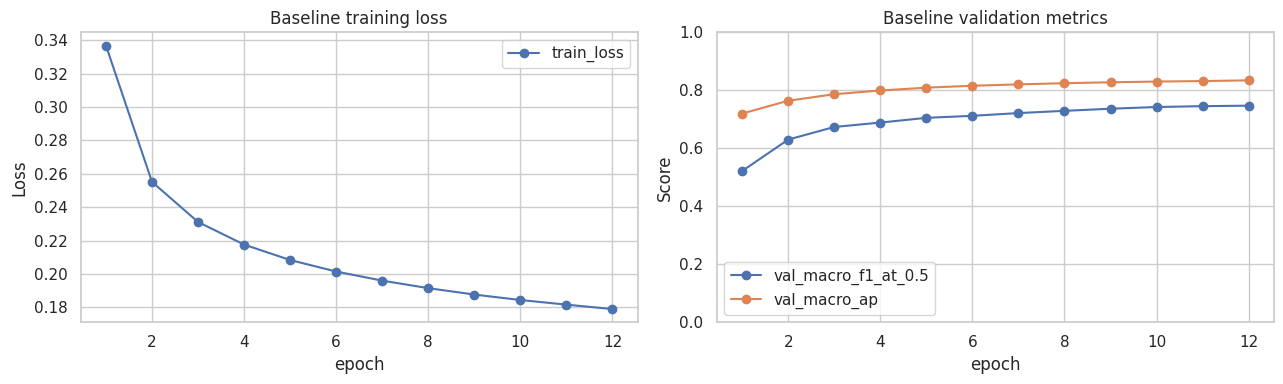

In [11]:
if baseline_history:
    baseline_history_df = pd.DataFrame(baseline_history)
elif BASELINE_HISTORY_PATH.exists():
    baseline_history_df = pd.read_csv(BASELINE_HISTORY_PATH)
    print("Loaded saved training history:", BASELINE_HISTORY_PATH)
else:
    baseline_history_df = pd.DataFrame()

if baseline_history_df.empty:
    print(
        "The checkpoint is available, but no epoch-by-epoch history CSV was found. "
        "Evaluation can still run normally."
    )
else:
    display(baseline_history_df)

    required_history_columns = {
        "epoch",
        "train_loss",
        "val_macro_f1_at_0.5",
        "val_macro_ap",
    }
    if required_history_columns.issubset(baseline_history_df.columns):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        baseline_history_df.plot(
            x="epoch",
            y="train_loss",
            marker="o",
            ax=axes[0],
            title="Baseline training loss",
        )
        baseline_history_df.plot(
            x="epoch",
            y=["val_macro_f1_at_0.5", "val_macro_ap"],
            marker="o",
            ax=axes[1],
            title="Baseline validation metrics",
        )

        axes[0].set_ylabel("Loss")
        axes[1].set_ylabel("Score")
        axes[1].set_ylim(0, 1)
        plt.tight_layout()
        plt.show()
    else:
        print(
            "The saved history uses an older column format, so it is displayed "
            "above without attempting an incompatible plot."
        )


## 10. Held-out test evaluation at threshold 0.5

In [12]:
if not BASELINE_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Baseline checkpoint was not created: {BASELINE_MODEL_PATH}. "
        "Check the training-cell output before continuing."
    )

print("Loading baseline checkpoint:", BASELINE_MODEL_PATH)
baseline_checkpoint = torch.load(
    BASELINE_MODEL_PATH,
    map_location=device,
    weights_only=False,
)

if "model_state_dict" not in baseline_checkpoint:
    raise KeyError(
        "The checkpoint does not contain 'model_state_dict' and is not compatible "
        "with this baseline notebook."
    )

checkpoint_classes = baseline_checkpoint.get("classes")
if checkpoint_classes is not None and list(checkpoint_classes) != CLASSES:
    raise ValueError(
        f"Checkpoint classes {checkpoint_classes} do not match notebook classes {CLASSES}."
    )

baseline_model.load_state_dict(baseline_checkpoint["model_state_dict"])
baseline_model.to(device).eval()
print("Saved baseline weights loaded successfully.")

baseline_y_test, baseline_test_probs = collect_predictions(
    baseline_model,
    baseline_test_loader,
)

# A fixed 0.5 threshold is intentional: tuning it would make this baseline less
# basic and would weaken the scientific comparison with the final pipeline.
baseline_thresholds = np.full(len(CLASSES), 0.5, dtype=np.float32)
baseline_test_predictions = (
    baseline_test_probs >= baseline_thresholds
).astype(np.uint8)

baseline_metrics = {
    "macro_f1": float(f1_score(
        baseline_y_test,
        baseline_test_predictions,
        average="macro",
        zero_division=0,
    )),
    "micro_f1": float(f1_score(
        baseline_y_test,
        baseline_test_predictions,
        average="micro",
        zero_division=0,
    )),
    "macro_precision": float(precision_score(
        baseline_y_test,
        baseline_test_predictions,
        average="macro",
        zero_division=0,
    )),
    "macro_recall": float(recall_score(
        baseline_y_test,
        baseline_test_predictions,
        average="macro",
        zero_division=0,
    )),
    "macro_average_precision": float(average_precision_score(
        baseline_y_test,
        baseline_test_probs,
        average="macro",
    )),
}

try:
    baseline_metrics["macro_roc_auc"] = float(roc_auc_score(
        baseline_y_test,
        baseline_test_probs,
        average="macro",
    ))
except ValueError as error:
    baseline_metrics["macro_roc_auc"] = None
    print("Macro ROC-AUC could not be calculated:", error)

display(pd.Series(
    baseline_metrics,
    name="Frozen ResNet-50 baseline",
))

report_text = classification_report(
    baseline_y_test,
    baseline_test_predictions,
    target_names=CLASSES,
    zero_division=0,
)
print(report_text)

report_dict = classification_report(
    baseline_y_test,
    baseline_test_predictions,
    target_names=CLASSES,
    zero_division=0,
    output_dict=True,
)
per_class_metrics_df = pd.DataFrame(report_dict).T.loc[
    CLASSES,
    ["precision", "recall", "f1-score", "support"],
]
display(per_class_metrics_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1-score": "{:.4f}",
    "support": "{:.0f}",
}))

metrics_payload = {
    "checkpoint_path": str(BASELINE_MODEL_PATH),
    "checkpoint_epoch": baseline_checkpoint.get("epoch"),
    "metrics": baseline_metrics,
    "thresholds": dict(zip(CLASSES, baseline_thresholds.tolist())),
    "per_class_metrics": {
        class_name: {
            metric_name: float(metric_value)
            for metric_name, metric_value in report_dict[class_name].items()
        }
        for class_name in CLASSES
    },
}

with open(BASELINE_METRICS_PATH, "w") as file:
    json.dump(metrics_payload, file, indent=2, allow_nan=False)

print("Saved baseline metrics:", BASELINE_METRICS_PATH)


Loading baseline checkpoint: /content/drive/MyDrive/plant_project/baseline_frozen_resnet50/baseline_frozen_resnet50.pt
Saved baseline weights loaded successfully.


,Frozen ResNet-50 baseline
macro_f1,0.746068
micro_f1,0.759622
macro_precision,0.847271
macro_recall,0.675304
macro_average_precision,0.837220
macro_roc_auc,0.946531


                    precision    recall  f1-score   support

           complex       0.74      0.39      0.51       323
frog_eye_leaf_spot       0.83      0.67      0.74       653
           healthy       0.87      0.87      0.87       694
    powdery_mildew       0.95      0.73      0.83       191
              rust       0.88      0.74      0.80       312
              scab       0.82      0.64      0.72       857

         micro avg       0.84      0.69      0.76      3030
         macro avg       0.85      0.68      0.75      3030
      weighted avg       0.84      0.69      0.75      3030
       samples avg       0.72      0.72      0.71      3030



,precision,recall,f1-score,support
complex,0.7427,0.3932,0.5142,323
frog_eye_leaf_spot,0.8283,0.6723,0.7422,653
healthy,0.8739,0.8689,0.8714,694
powdery_mildew,0.9459,0.7330,0.8260,191
rust,0.8750,0.7404,0.8021,312
scab,0.8178,0.6441,0.7206,857


Saved baseline metrics: /content/drive/MyDrive/plant_project/baseline_frozen_resnet50/baseline_metrics.json


## 11. Confusion matrices and precision–recall curves

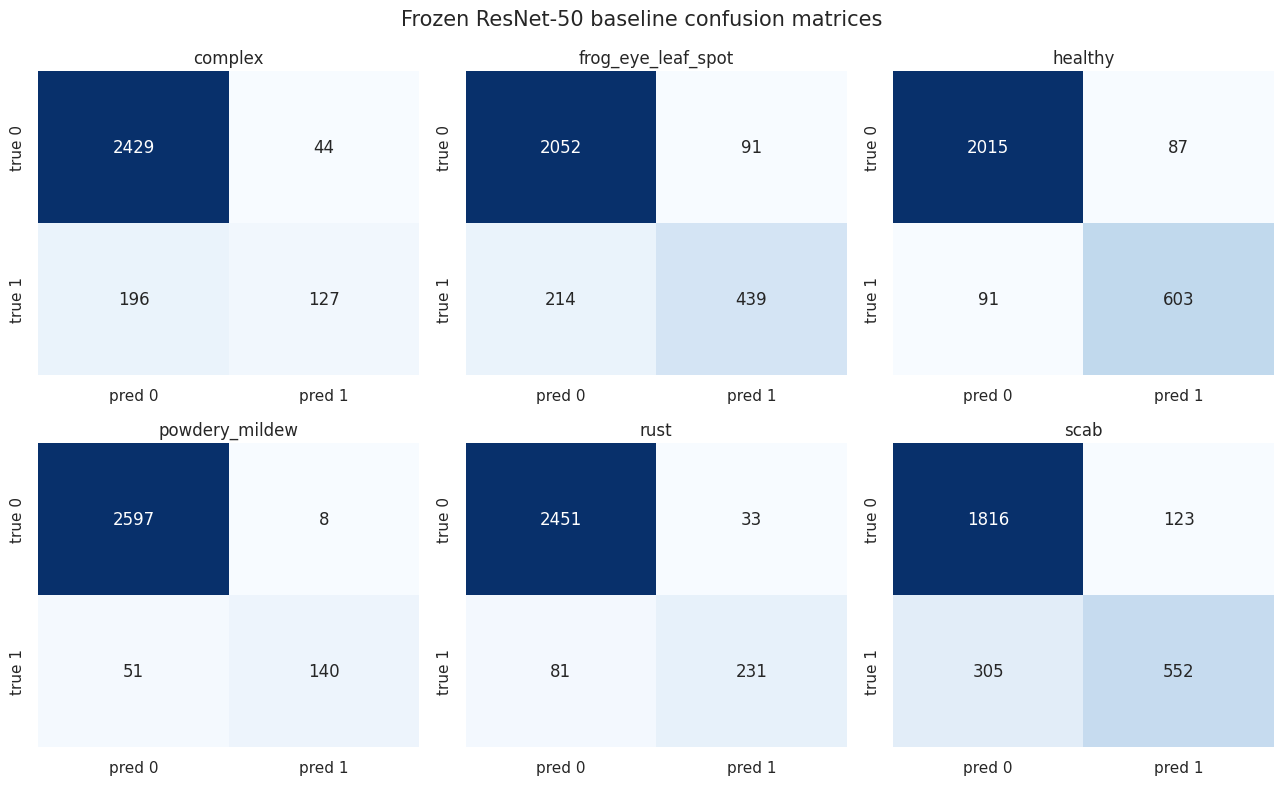

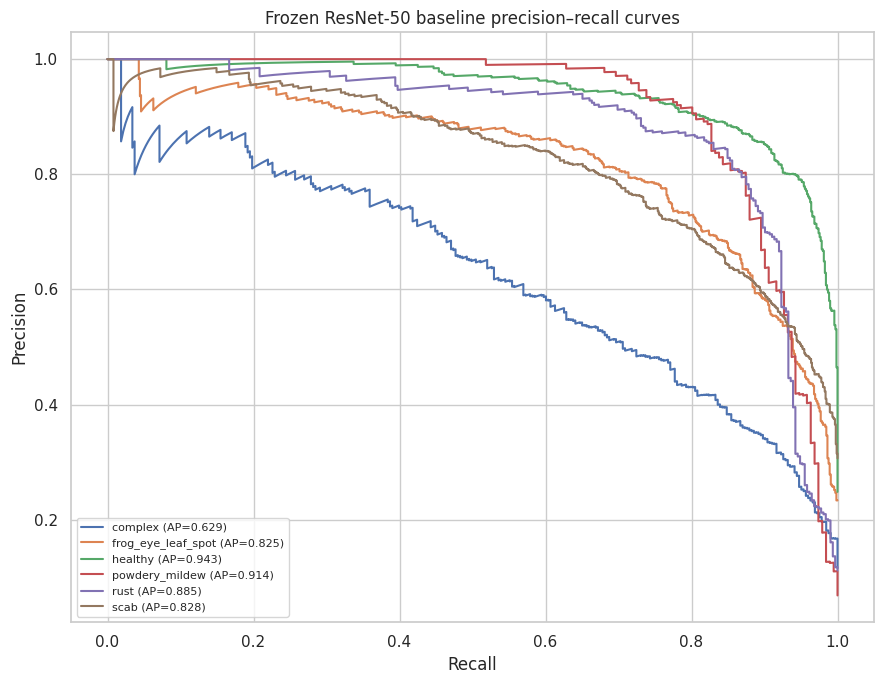

In [13]:
confusion = multilabel_confusion_matrix(
    baseline_y_test,
    baseline_test_predictions,
)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for axis, class_name, matrix in zip(
    axes.ravel(),
    CLASSES,
    confusion,
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["pred 0", "pred 1"],
        yticklabels=["true 0", "true 1"],
    )
    axis.set_title(class_name)

plt.suptitle("Frozen ResNet-50 baseline confusion matrices", fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
for index, class_name in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(
        baseline_y_test[:, index],
        baseline_test_probs[:, index],
    )
    ap = average_precision_score(
        baseline_y_test[:, index],
        baseline_test_probs[:, index],
    )
    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP={ap:.3f})",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Frozen ResNet-50 baseline precision–recall curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 12. Compare with the final model

Loaded final-model metrics from: /content/drive/MyDrive/plant_project/resnet50_complete/test_metrics.json


,macro_f1,micro_f1,macro_precision,macro_recall,macro_average_precision,macro_roc_auc
Frozen ResNet-50 baseline,0.7461,0.7596,0.8473,0.6753,0.8372,0.9465
Final fine-tuned ResNet-50,0.8934,0.8985,0.8765,0.9130,0.9468,0.9870


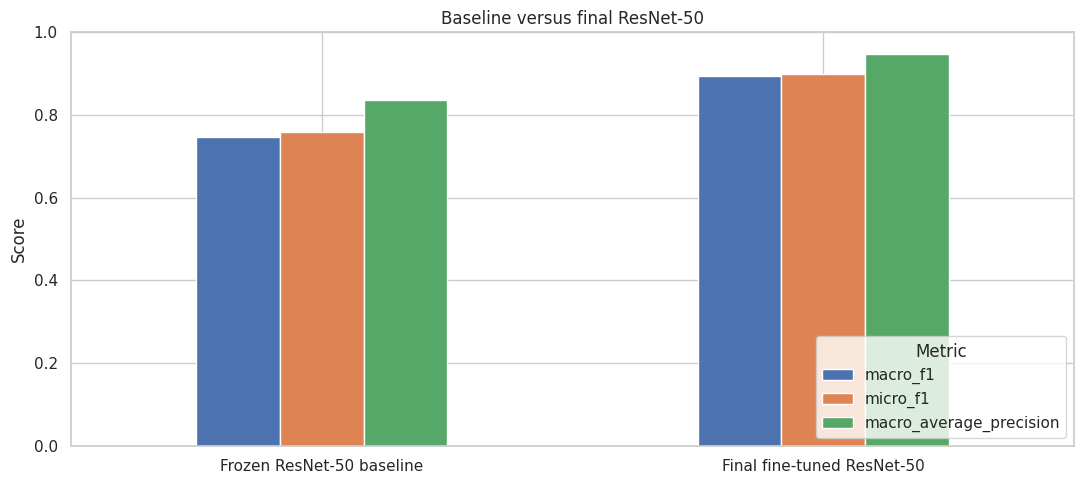

Saved comparison: /content/drive/MyDrive/plant_project/baseline_frozen_resnet50/baseline_vs_final.csv


In [14]:
def load_final_model_metrics():
    for candidate_path in FINAL_METRICS_CANDIDATES:
        if candidate_path.exists():
            with open(candidate_path) as file:
                payload = json.load(file)
            metrics = payload.get("test_metrics", payload.get("metrics", payload))
            print("Loaded final-model metrics from:", candidate_path)
            return metrics

    if FINAL_COMPLETE_CHECKPOINT_PATH.exists():
        payload = torch.load(
            FINAL_COMPLETE_CHECKPOINT_PATH,
            map_location="cpu",
            weights_only=False,
        )
        metrics = payload.get("test_metrics", payload.get("metrics"))
        if metrics is not None:
            print(
                "Loaded final-model metrics from checkpoint:",
                FINAL_COMPLETE_CHECKPOINT_PATH,
            )
            return metrics

    return None


final_metrics = load_final_model_metrics()

if final_metrics is not None:
    # Accept the shorter key used by some older versions of the final notebook.
    final_metrics = dict(final_metrics)
    if (
        "macro_average_precision" not in final_metrics
        and "macro_ap" in final_metrics
    ):
        final_metrics["macro_average_precision"] = final_metrics["macro_ap"]

    metric_order = [
        "macro_f1",
        "micro_f1",
        "macro_precision",
        "macro_recall",
        "macro_average_precision",
        "macro_roc_auc",
    ]
    comparison_rows = {
        "Frozen ResNet-50 baseline": baseline_metrics,
        "Final fine-tuned ResNet-50": final_metrics,
    }
    comparison_df = pd.DataFrame(comparison_rows).T
    available_metrics = [
        metric
        for metric in metric_order
        if metric in comparison_df.columns
        and comparison_df[metric].notna().any()
    ]
    comparison_df = comparison_df[available_metrics].apply(
        pd.to_numeric,
        errors="coerce",
    )
    comparison_df.to_csv(COMPARISON_PATH)

    display(comparison_df.style.format("{:.4f}", na_rep="N/A"))

    chart_metrics = [
        metric
        for metric in [
            "macro_f1",
            "micro_f1",
            "macro_average_precision",
        ]
        if metric in comparison_df.columns
    ]

    if chart_metrics:
        comparison_df[chart_metrics].plot(
            kind="bar",
            figsize=(11, 5),
        )
        plt.ylabel("Score")
        plt.ylim(0, 1)
        plt.title("Baseline versus final ResNet-50")
        plt.xticks(rotation=0)
        plt.legend(title="Metric", loc="lower right")
        plt.tight_layout()
        plt.show()

    print("Saved comparison:", COMPARISON_PATH)
else:
    print("Baseline evaluation is complete.")
    print(
        "Final-model metrics were not found in the expected JSON files or in:"
    )
    print(FINAL_COMPLETE_CHECKPOINT_PATH)
    print(
        "This does not affect the baseline results; only the automatic comparison "
        "is unavailable."
    )


## Interpretation

This experiment compares a basic frozen-feature transfer-learning system with the complete final pipeline. The comparison does not isolate only one improvement: the final system also uses backbone fine-tuning, augmentation, class-weighted loss, differential learning rates and validation-tuned class thresholds.
